In [2]:
# Import required libraries and packages
import sys
sys.path.insert(1, "/mnt/c/Users/PC/Desktop/wikolego-repository/ai-path/ml-next-step/src")

import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

import config

print(tf.__version__)

2.10.0


In [3]:
# Load MNIST data
df = pd.read_csv(config.NEW_DATA_PATH)
df = df.drop(columns=["id"])

# initialize training data
df_train = df.loc[df["kfold"] != 1, :]
df_test = df.loc[df["kfold"] == 1, :]

df_train = df_train.drop(columns=["kfold"])
df_test = df_test.drop(columns=["kfold"])

784
8000


array([6, 6, 5, ..., 3, 8, 4])

Epoch 1/50
250/250 [==============================] - 1s 4ms/step - loss: 3.8225 - sparse_categorical_accuracy: 0.8195 - val_loss: 0.9666 - val_sparse_categorical_accuracy: 0.8700
Epoch 2/50
250/250 [==============================] - 1s 4ms/step - loss: 0.4383 - sparse_categorical_accuracy: 0.9271 - val_loss: 0.5711 - val_sparse_categorical_accuracy: 0.9155
Epoch 3/50
250/250 [==============================] - 1s 4ms/step - loss: 0.2825 - sparse_categorical_accuracy: 0.9409 - val_loss: 0.5283 - val_sparse_categorical_accuracy: 0.9165
Epoch 4/50
250/250 [==============================] - 1s 4ms/step - loss: 0.2134 - sparse_categorical_accuracy: 0.9586 - val_loss: 0.5611 - val_sparse_categorical_accuracy: 0.9120
Epoch 5/50
250/250 [==============================] - 1s 4ms/step - loss: 0.2047 - sparse_categorical_accuracy: 0.9601 - val_loss: 0.5525 - val_sparse_categorical_accuracy: 0.9350
Epoch 6/50
250/250 [==============================] - 1s 4ms/step - loss: 0.2027 - sparse_categorica

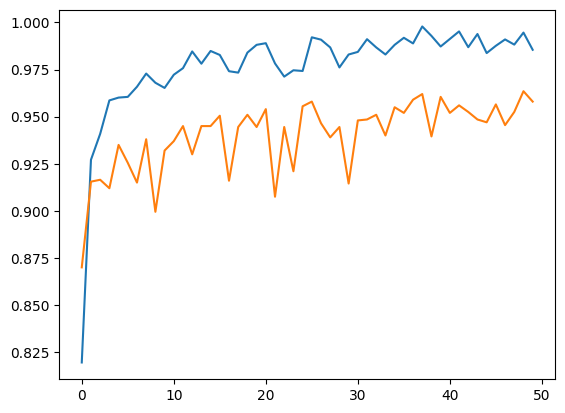

In [13]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(512, activation="relu", input_shape=(len(X_data[1]), )), # input layer
    # tf.keras.layers.Dropout(0.125),
    tf.keras.layers.Dense(512, activation="relu"),
    # tf.keras.layers.Dropout(0.125),
    tf.keras.layers.Dense(512, activation="relu"),
    # tf.keras.layers.Dropout(0.125),
    tf.keras.layers.Dense(10, activation="softmax") # output layer
])

# Compile model
model.compile(
    optimizer="Adam",
    loss="SparseCategoricalCrossentropy",
    metrics=["SparseCategoricalAccuracy"]
)

# Fit model
result = model.fit(
    df_train.drop(columns=["label"]).values,
    df_train.loc[:, "label"].values,
    # batch_size=32,
    epochs=50,
    validation_data=(df_test.drop(columns=["label"]).values, df_test.loc[:, "label"].values),
)

# Predict and print predictions
predictions = max(result.history["sparse_categorical_accuracy"])
print(predictions)

if True:
    plt.plot(result.history["sparse_categorical_accuracy"])
    plt.plot(result.history["val_sparse_categorical_accuracy"])
    plt.show()

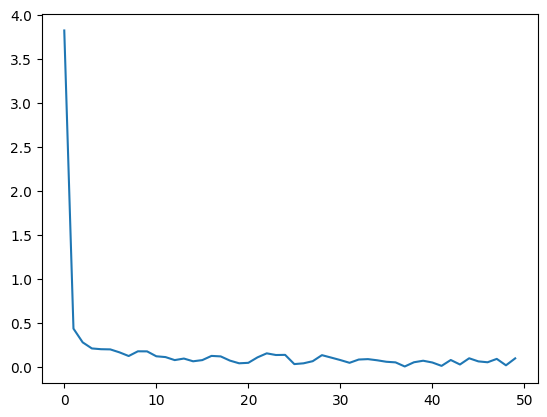

In [14]:
plt.plot(result.history["loss"])
plt.show()